<a href="https://colab.research.google.com/github/itmin2407/AIFFEL_quest_eng/blob/main/Graph_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph RAG

## 개요
Graph RAG는 문서 내 개체(Entity)와 관계(Relationship)를 **지식 그래프**로 구축하여,
단순 벡터 검색이 놓치는 복잡한 연결 관계를 파악합니다.

### 핵심 구조
1. **Entity Extraction**: LLM으로 문서에서 개체(명사/개념) 추출
2. **Relation Extraction**: 개체 간 관계(동사/서술) 추출
3. **Knowledge Graph Build**: NetworkX로 그래프 구축
4. **Graph Retrieval**: 쿼리 관련 서브그래프 탐색
5. **Community Detection**: 연관된 지식 군집화
6. **Generation**: 그래프 기반 컨텍스트로 답변 생성

### 장점
- 여러 문서에 흩어진 정보 연결
- 멀티-홉 추론 (A→B→C 관계 파악)
- 'What are the connections between X and Y?' 유형 질문에 강점

### Re-ranking 전략
- STUFF / REFINE / MAP-REDUCE / MAP-RERANK

In [1]:
!pip install chromadb==0.4.24 \
  sentence-transformers==2.7.0 \
  tiktoken==0.7.0 \
  pypdf \
  networkx \
  ragas \
  datasets \
  koreanize_matplotlib

!pip install -U \
  "langchain==0.3.14" \
  "langchain-core==0.3.63" \
  "langchain-community==0.3.14" \
  "langchain-openai==0.3.10" \
  "langchain-chroma==0.1.4"


  Using cached openai-2.29.0-py3-none-any.whl.metadata (29 kB)
INFO: pip is looking at multiple versions of langchain-openai to determine which version is compatible with other requirements. This could take a while.
  Using cached langchain_openai-1.1.11-py3-none-any.whl.metadata (3.1 kB)
  Using cached langchain_openai-1.1.10-py3-none-any.whl.metadata (3.1 kB)
  Using cached langchain_openai-1.1.9-py3-none-any.whl.metadata (3.1 kB)
  Using cached langchain_openai-1.1.8-py3-none-any.whl.metadata (3.1 kB)
  Using cached langchain_openai-1.1.7-py3-none-any.whl.metadata (2.6 kB)
  Using cached langchain_openai-1.1.6-py3-none-any.whl.metadata (2.6 kB)
  Using cached langchain_openai-1.1.5-py3-none-any.whl.metadata (2.6 kB)
INFO: pip is still looking at multiple versions of langchain-openai to determine which version is compatible with other requirements. This could take a while.
  Using cached langchain_openai-1.1.4-py3-none-any.whl.metadata (2.6 kB)
  Using cached langchain_openai-1.1.3-p

In [64]:
import os
from google.colab import drive, userdata

from typing import List, Tuple, Dict, Optional
import networkx as nx
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma

from langchain.output_parsers.regex import RegexParser
from langchain.chains import RetrievalQA

from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from langchain_core.retrievers import BaseRetriever
from IPython.display import Markdown, display
import tiktoken

import re
import json

import networkx as nx

from difflib import SequenceMatcher

import matplotlib as mpl
import matplotlib.pyplot as plt
import koreanize_matplotlib  # rcParams 자동 설정

from datasets import Dataset
from ragas import evaluate
from ragas.metrics import (
    Faithfulness,
    ResponseRelevancy,
    LLMContextPrecisionWithoutReference,
)

from dotenv import load_dotenv

from chromadb.config import Settings
from langchain_community.vectorstores import Chroma
import logging

import warnings
import requests, time

/tmp/ipykernel_56860/2165433621.py:34: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import (
/tmp/ipykernel_56860/2165433621.py:34: DeprecationWarning: Importing ResponseRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ResponseRelevancy
  from ragas.metrics import (
/tmp/ipykernel_56860/2165433621.py:34: DeprecationWarning: Importing LLMContextPrecisionWithoutReference from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import LLMContextPrecisionWithoutReference
  from ragas.metrics import (


In [71]:
os.environ["ANONYMIZED_TELEMETRY"] = "false"

# 전역 레이아웃/폰트 설정
plt.rcParams["figure.constrained_layout.use"] = True
plt.rc("font", family="NanumGothic")
plt.rcParams["axes.unicode_minus"] = False

# chromadb 전체 텔레메트리 로거를 묵음 처리
logging.getLogger("chromadb.telemetry").setLevel(logging.CRITICAL)
logging.getLogger("chromadb.telemetry.product").setLevel(logging.CRITICAL)
logging.getLogger("chromadb.telemetry.product.posthog").setLevel(logging.CRITICAL)

try:
    import koreanize_matplotlib  # 자동으로 한글 폰트 설정
except ImportError:
    # koreanize_matplotlib 없을 경우, 직접 설정
    plt.rcParams["font.family"] = "NanumGothic"

In [43]:
# os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
# os.environ['OPENAI_API_KEY'] = 'your-api-key-here'

In [44]:
drive.mount('/content/drive')

# .env 파일 로드
load_dotenv('/content/drive/MyDrive/.env')

# 환경변수에서 API 키 가져오기
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
# api_key = os.environ["OPENAI_API_KEY"]
# headers = {"Authorization": f"Bearer {api_key}"}

# now = int(time.time())
# start_time = now - 30 * 24 * 60 * 60

# params = {
#     "start_time": start_time,
#     "bucket_width": "1d",
#     "limit": 30,
# }

# usage = requests.get(
#     "https://api.openai.com/v1/organization/usage/completions",
#     headers=headers,
#     params=params,
# ).json()

# print(usage)

{'error': "You have insufficient permissions for this operation. Missing scopes: api.usage.read. Check that you have the correct role in your organization, and if you're using a restricted API key, that it has the necessary scopes."}


In [45]:
tokenizer = tiktoken.get_encoding('cl100k_base')
def tiktoken_len(text): return len(tokenizer.encode(text))

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0.0)
embedding_model = OpenAIEmbeddings(model='text-embedding-3-small')

## 1. 문서 로드 및 인덱싱

In [46]:
loader = WebBaseLoader('https://en.wikipedia.org/wiki/Hermann_Hesse')
pages = loader.load()

splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100, length_function=tiktoken_len)
docs = splitter.split_documents(pages)

CHROMA_SETTINGS = Settings(
    anonymized_telemetry=False,
    is_persistent=False,
)

# 처리 속도를 위해 첫 20개 청크만 사용
docs = docs[:20]

# vectorstore = Chroma.from_documents(docs, embedding_model)
vectorstore = Chroma.from_documents(
    docs,
    embedding_model,
    client_settings=CHROMA_SETTINGS,
    collection_name="hesse_graph_rag",
)

print(f'인덱싱 완료: {len(docs)}개 청크')

인덱싱 완료: 20개 청크


In [47]:
def extract_entities_relations(text, llm):
    """문서에서 개체와 관계를 추출하여 JSON으로 반환"""

    prompt = """당신은 지식 그래프 전문가입니다.
    제시된 텍스트에서 다음 '트리플' 구조를 최대한 많이 추출하세요.
    형식: [{"source": "주체", "target": "대상", "relation": "관계"}]

    추출 대상 예시:
    - (인물) 은/는 (작품) 을/를 (집필했다)
    - (작품) 은/는 (철학) 의 (영향을 받았다)
    - (인물) 은/는 (국적) (출신이다)

    텍스트: {text}
    """

    try:
      response = llm.invoke(f"{prompt}\n\nText: {text}")
      content = response.content if hasattr(response, "content") else str(response)

      if not content or not content.strip():
          print("추출 에러: LLM 응답이 비어 있음")
          return []

      # 코드블록/마크다운 제거
      clean_content = re.sub(r"```json|```", "", content).strip()

      # JSON 이 아닐 가능성 대비해서, 대괄호/중괄호 부분만 추출 시도
      # LLM이 앞뒤로 설명을 덧붙이는 경우 대비, 여러 줄 + 설명 섞인 경우 방어
      # JSON 블럭만 잘라내기
      json_match = re.search(r"(\[.*\]|\{.*\})", clean_content, re.DOTALL)
      if not json_match:
        print("JSON 블럭을 찾지 못했음:", repr(clean_content[:200]))
        return []

      json_str = json_match.group(1).strip()

      # JSON 파싱
      try:
        parsed = json.loads(json_str)
      except json.JSONDecodeError as je:
        print("JSON 파싱 실패:", je)
        print("raw content snippet:", repr(clean_content[:200]))
        return []

      # 5) 기대 타입 보정/검증
      if isinstance(parsed, dict):
        parsed = [parsed]
      if not isinstance(parsed, list):
        print("예상치 못한 파싱 결과 타입:", type(parsed))
        return []

      # 최소한 source/target 있는 것만 필터링
      triples = []
      for t in parsed:
        if isinstance(t, dict) and "source" in t and "target" in t:
          triples.append(
              {
                  "source": t["source"],
                  "target": t["target"],
                  "relation": t.get("relation", "related"),
              }
          )

      return triples

    except Exception as e:
      print(f"추출 에러(전체 예외): {e}")
      return []

## 2. 지식 그래프 구축

In [48]:
# Entity & Relation 추출 프롬프트
kg_extraction_prompt = ChatPromptTemplate.from_messages([
    ('system',
     'Extract entities and relationships from the text. '
     'Output ONLY valid JSON with this structure: '
     '{"entities": ["entity1", "entity2"], "relations": [["entity1", "relation", "entity2"]]}'
     'Extract 3-8 entities and 2-6 relations. Keep entities as short noun phrases.'),
    ('human', 'Text: {text}')
])

kg_chain = kg_extraction_prompt | llm | StrOutputParser()

def extract_graph_from_doc(doc: Document) -> Tuple[List[str], List[Tuple]]:
    """단일 문서에서 Entity-Relation 추출"""
    try:
        response = kg_chain.invoke({'text': doc.page_content[:600]})
        # JSON 파싱 시도
        start = response.find('{')
        end = response.rfind('}') + 1
        if start >= 0 and end > start:
            data = json.loads(response[start:end])
            entities = data.get('entities', [])
            relations = [tuple(r) for r in data.get('relations', []) if len(r) == 3]
            return entities, relations
    except Exception as e:
        pass
    return [], []

print('Knowledge Graph 추출 함수 정의 완료')

Knowledge Graph 추출 함수 정의 완료


In [49]:
G = nx.DiGraph()
doc_graph_map = {}

print(f"총 {len(docs)}개 문서 분석 시작...")

for i, doc in enumerate(docs):
  doc_key = f"doc_{i}"

  # 문서에서 트리플 추출
  triples = extract_entities_relations(doc.page_content, llm)
  if triples is None:
    print(f"{doc_key}: triples is None, skip")
    triples = []

  doc_key = f'doc_{i}'
  # 2. 문서 맵에 데이터 저장
  doc_graph_map[doc_key] = {'doc': doc, 'triples': triples}

  for t in triples:
    if 'source' in t and 'target' in t:
      # 그래프에 엣지 추가
      G.add_edge(t['source'], t['target'], relation=t.get('relation', 'related'))

      # 노드 속성에 문서 키 저장
      for node_name in [t['source'], t['target']]:
        if 'docs' not in G.nodes[node_name]:
          G.nodes[node_name]['docs'] = [doc_key]
        else:
          if doc_key not in G.nodes[node_name]['docs']:
            G.nodes[node_name]['docs'].append(doc_key)

  if (i+1) % 5 == 0:
      print(f"{i+1}/{len(docs)} 문서 완료 (현재 노드 수: {G.number_of_nodes()})")

print(f"\n[최종 결과] 노드 수: {G.number_of_nodes()}, 엣지 수: {G.number_of_edges()}")

총 20개 문서 분석 시작...
5/20 문서 완료 (현재 노드 수: 75)
10/20 문서 완료 (현재 노드 수: 201)
15/20 문서 완료 (현재 노드 수: 376)
20/20 문서 완료 (현재 노드 수: 433)

[최종 결과] 노드 수: 433, 엣지 수: 423


## 3. Graph RAG Retriever
그래프 구조를 활용한 서브그래프 기반 검색

In [50]:
# 1. 유사도 계산용 유틸리티 함수
def get_similarity(a, b):
    """두 문자열 간의 유사도를 0~1 사이로 반환"""
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()


In [51]:
class GraphRAGRetriever(BaseRetriever):
    """
    Graph RAG 전용 리트리버
    1. 쿼리에서 핵심 엔티티 추출
    2. 그래프에서 관련 노드 탐색 (N-hop)
    3. 연결된 문서 반환
    """
    graph: object
    doc_graph_map: dict
    vectorstore: object
    llm: object
    k: int = 4
    hop_depth: int = 2  # N-hop 탐색 깊이
    similarity_threshold: float = 0.6  # 유사도 임계값 추가

    class Config:
        arbitrary_types_allowed = True

    def _extract_query_entities(self, query: str) -> List[str]:
        """쿼리에서 핵심 엔티티 추출"""
        entity_prompt = ChatPromptTemplate.from_messages([
            ('system', 'Extract key entities from the query as a comma-separated list. Output ONLY entity names.'),
            ('human', 'Query: {query}')
        ])
        chain = entity_prompt | self.llm | StrOutputParser()
        response = chain.invoke({'query': query})
        return [e.strip() for e in response.split(',') if e.strip()]


    def _find_graph_nodes(self, query_entities: List[str]) -> List[str]:
        """쿼리 엔티티와 관련된 그래프 노드 탐색 (유사도 매칭 반영)"""
        matched_nodes = set()
        graph_nodes = list(self.graph.nodes())

        for q_entity in query_entities:
            q_lower = q_entity.lower()

            for node in graph_nodes:
                n_lower = node.lower()

                # 유사도 매칭 로직 적용
                # 1. 포함 관계 (Hesse <-> Hermann Hesse)
                # 2. 유사도 점수 (헤세 <-> 헤르만헤세)
                is_match = (q_lower in n_lower or n_lower in q_lower) or \
                           (get_similarity(q_entity, node) >= self.similarity_threshold)

                if is_match:
                    matched_nodes.add(node)
                    # N-hop 이웃 탐색 (연결된 맥락 확장)
                    try:
                        # ego_graph는 중심 노드로부터 N-hop 이내의 모든 노드를 반환합니다.
                        neighbors = list(nx.ego_graph(self.graph, node, radius=self.hop_depth).nodes())
                        matched_nodes.update(neighbors) # 관련 노드 전체 추가
                    except Exception as e:
                        pass

        return list(matched_nodes)


    def _get_relevant_documents(self, query: str, *, run_manager=None) -> List[Document]:
        # 쿼리 엔티티 추출
        query_entities = self._extract_query_entities(query)
        print(f'[GraphRAG] 쿼리 엔티티: {query_entities}')

        # 그래프 노드 탐색
        relevant_nodes = self._find_graph_nodes(query_entities)
        print(f'[GraphRAG] 관련 노드 수: {len(relevant_nodes)}')

        # 관련 문서 수집
        relevant_doc_keys = set()
        for node in relevant_nodes:
            if self.graph.has_node(node):
                node_docs = self.graph.nodes[node].get('docs', [])
                relevant_doc_keys.update(node_docs)

        # 그래프 결과 없으면 벡터 검색 폴백
        if not relevant_doc_keys:
            print('[GraphRAG] 그래프 결과 없음 -> 벡터 검색 폴백')
            return self.vectorstore.similarity_search(query, k=self.k)

        graph_docs = [self.doc_graph_map[key]['doc'] for key in relevant_doc_keys if key in self.doc_graph_map]

        # 벡터 검색과 통합 (Hybrid)
        vector_docs = self.vectorstore.similarity_search(query, k=self.k)

        # 중복 제거 후 반환
        all_docs = graph_docs + vector_docs
        seen = set()
        unique_docs = []
        for doc in all_docs:
            key = doc.page_content[:80]
            if key not in seen:
                seen.add(key)
                unique_docs.append(doc)

        print(f'[GraphRAG] 최종 문서 수: {len(unique_docs[:self.k])}')
        return unique_docs[:self.k]

graph_retriever = GraphRAGRetriever(
    graph=G,
    doc_graph_map=doc_graph_map,
    vectorstore=vectorstore,
    llm=llm,
    k=4,
    hop_depth=2
)
print('GraphRAGRetriever 정의 완료')


GraphRAGRetriever 정의 완료


/tmp/ipykernel_56860/2618418219.py:1: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class GraphRAGRetriever(BaseRetriever):


## 4. Graph RAG - map-rerank

In [52]:
query = 'What are the connections between Hermann Hesse, his novels, and Eastern philosophy?'

# 1) RegexParser
output_parser = RegexParser(
    regex=r"점수:\s*\[?(\d+)\]?\s*\n답변:\s*(.*)",
    output_keys=["score", "answer"],
)

# 2) MAP-RERANK 프롬프트
MAP_PROMPT = PromptTemplate(
    template="""지시사항: 다음 자료를 바탕으로 질문에 답하고, 그 답변이 질문과 얼마나 관련 있는지 0에서 100 사이의 점수를 매겨주세요.
형식은 반드시 아래와 같이 '점수: [숫자]', '답변: [내용]' 순서로 작성하세요.

자료: {context}
질문: {question}

결과:
점수: [점수]
답변: [답변]""",
    input_variables=["context", "question"],
    output_parser=output_parser,
)

# 3) RetrievalQA - map_rerank
qa = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="map_rerank",
    retriever=graph_retriever,
    chain_type_kwargs={
        "prompt": MAP_PROMPT,
    },
)

result = qa.invoke({"query": query})
print('=== [Graph RAG] MAP-RERANK ===')
display(Markdown(result['result']))

[GraphRAG] 쿼리 엔티티: ['Hermann Hesse', 'novels', 'Eastern philosophy']
[GraphRAG] 관련 노드 수: 303
[GraphRAG] 최종 문서 수: 4


/usr/local/lib/python3.12/dist-packages/langchain/chains/llm.py:369: UserWarning: The apply_and_parse method is deprecated, instead pass an output parser directly to LLMChain.
  warnings.warn(


=== [Graph RAG] MAP-RERANK ===


Hermann Hesse's connection to Eastern philosophy is notably reflected in his novella "Siddhartha," which showcases his love for Indian culture and Buddhist philosophy. This interest in Eastern thought had developed earlier in his life and influenced his writing, particularly in exploring themes of self-discovery and spiritual enlightenment. Additionally, his experiences during his time in Ticino, where he found happiness and productivity, likely contributed to the philosophical depth in his works, including "Klingsor's Last Summer" and "Narcissus and Goldmund."

## 5. 그래프 시각화

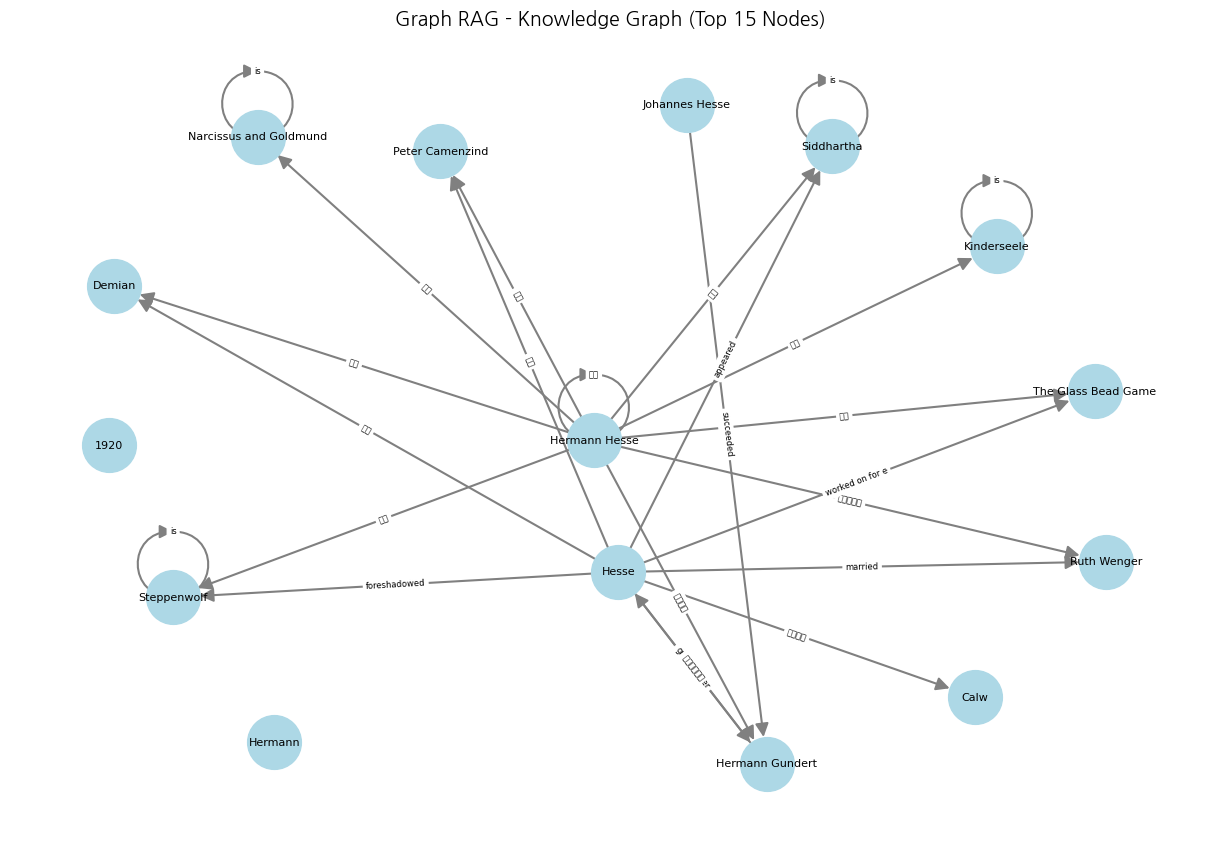

그래프 시각화 완료 (노드: 15, 엣지: 24)


In [75]:
# 상위 연결 노드만 시각화
top_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:15]
subgraph = G.subgraph([n for n, d in top_nodes])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subgraph, k=2, seed=42)

nx.draw(
    subgraph,
    pos,
    with_labels=True,
    node_color='lightblue',
    node_size=1500,
    font_size=8,
    arrows=True,
    edge_color='gray',
    arrowsize=20,
    width=1.5
)

edge_labels = {
    (u, v): d.get('relation', '')[:15]
    for u, v, d in subgraph.edges(data=True)
}

nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels, font_size=6)
plt.title('Graph RAG - Knowledge Graph (Top 15 Nodes)', fontsize=14)

plt.show()

print(f'그래프 시각화 완료 (노드: {subgraph.number_of_nodes()}, 엣지: {subgraph.number_of_edges()})')


In [54]:
# Ragas 평가를 위한 데이터 준비
# 실제 사용 시에는 여러 쿼리와 그에 대한 답변, 컨텍스트를 포함하는 데이터셋을 사용해야 함.

# 이전 쿼리와 답변 사용
question_eval = result['query']
answer_eval = result['result']

# 해당 쿼리에 대한 GraphRAGRetriever의 컨텍스트를 가져와서 재사용.
# 해당 부분은 실제 평가 데이터셋을 구성할 때, 각 질문에 대한 retriever의 출력을 저장해야 함.
retrieved_docs_eval = graph_retriever._get_relevant_documents(question_eval)
contexts_eval = [doc.page_content for doc in retrieved_docs_eval]

# Ragas 데이터셋 형식에 맞게 데이터 구성
data = {
    'question': [question_eval],
    'answer': [answer_eval],
    'contexts': [contexts_eval],
    # 'ground_truth': ['실제 정답을 추가 (옵션)'] # 정답이 있다면 추가
}

# Dataset 객체 생성
eval_dataset = Dataset.from_dict(data)

print("Ragas 평가 데이터셋 준비 완료:")
print(eval_dataset)

[GraphRAG] 쿼리 엔티티: ['Hermann Hesse', 'novels', 'Eastern philosophy']
[GraphRAG] 관련 노드 수: 303
[GraphRAG] 최종 문서 수: 4
Ragas 평가 데이터셋 준비 완료:
Dataset({
    features: ['question', 'answer', 'contexts'],
    num_rows: 1
})


In [55]:
retriever = graph_retriever

def graph_rag_qa(question: str):
  """
  단일 질문을 받아서
  1) 그래프 RAG retriever로 관련 컨텍스트(문서 조각들)를 찾고
  2) LLM/체인을 통해 답변을 생성한 뒤
  3) (답변, 컨텍스트 리스트[str])을 반환 강제
  """
  # 1. 그래프 기반 컨텍스트 검색
  try:
    retrieved_docs = retriever.invoke(question)
  except AttributeError:
    # 구버전/다른 구현일 경우
    retrieved_docs = retriever.get_relevant_documents(question)

  # 2. 컨텍스트 텍스트만 추출
  contexts = [d.page_content for d in retrieved_docs]

  # 3. LLM 체인으로 답변 생성
  if "qa_chain" in globals():
    result = qa_chain.invoke({"question": question, "context": "\n\n".join(contexts)})

  else:
    prompt = f"""
You are a helpful assistant answering questions about Hermann Hesse.
Use ONLY the following context to answer the question.

Context:
{chr(10).join(contexts)}

Question: {question}
Answer in English.
"""
    result = llm.invoke(prompt)

  # 3. result를 항상 문자열로 변환
  #   - OpenAI Chat 모델: AIMessage -> result.content
  #   - LCEL 체인: dict 또는 문자열일 수 있음
  from langchain_core.messages import AIMessage

  if isinstance(result, AIMessage):
    answer = result.content
  elif isinstance(result, dict):
    # lc-runnable chain 경우
    answer = result.get("result") or result.get("answer") or str(result)
  else:
    # 이미 str 이거나 기타 타입
    answer = str(result)

  return answer, contexts


In [56]:
# Ragas 평가 실행

queries = [
    "What are the main themes in Hermann Hesse's novels?",
    "Which of Hermann Hesse's works earned him the Nobel Prize in Literature?",
    "What spiritual or philosophical traditions influenced Hermann Hesse?",
    "What is the core plot and spiritual message of Siddhartha?",
    "What inner conflict is depicted in Steppenwolf?"
]

faith_metric = Faithfulness()
rel_metric = ResponseRelevancy()

questions_list = []
answers_list = []
contexts_list = []

for q in queries:
  answer, contexts = graph_rag_qa(q)
  questions_list.append(q)
  answers_list.append(answer)
  # ragas는 컨텍스트를 리스트[str] 형태 권장
  contexts_list.append(contexts if isinstance(contexts, list) else [contexts])

  # 1개 샘플짜리 Dataset 생성
  single_ds = Dataset.from_dict(
      {
          "question": [q],
          "answer": [answer],
          "contexts": [contexts if isinstance(contexts, list) else [contexts]],
      }
  )

  # 메트릭 개별 계산 (버전에 따라 .score / .batch 가 다를 수 있음)
  single_res = evaluate(
      single_ds,
      metrics=[faith_metric, rel_metric],
      llm=llm,
      embeddings=embedding_model,
  )

  # f_score = single_res["faithfulness"]
  # r_score = single_res["answer_relevancy"]

  f_raw = single_res["faithfulness"]
  r_raw = single_res["answer_relevancy"]

  # 리스트/넘파이/스칼라 모두 대응
  def _to_scalar(x):
    # list 또는 tuple
    if isinstance(x, (list, tuple)):
        return float(x[0]) if len(x) > 0 else float("nan")
    # 넘파이 배열일 수도 있음
    try:
        import numpy as np
        if isinstance(x, np.ndarray):
            return float(x.reshape(-1)[0])
    except Exception:
        pass
    # 스칼라
    return float(x)

  f_score = _to_scalar(f_raw)
  r_score = _to_scalar(r_raw)

  print(f"\n[Question] {q}")
  print(f"  faithfulness       : {f_score:.4f}")
  print(f"  answer_relevancy   : {r_score:.4f}")
  print()
  print()

# ----- 전체 평균 -----
# RAGAS용 Dataset 생성
eval_dataset = Dataset.from_dict(
    {
        "question": questions_list,   # list[str]
        "answer": answers_list,       # list[str]
        "contexts": contexts_list,    # list[list[str]]
        # ground_truth가 있을 경우, "ground_truth" 관련 K, V 추가
    }
)

# 사용할 메트릭 설정
metrics_to_evaluate = [
    Faithfulness(),
    ResponseRelevancy(),  # answer_relevance 대체
    # ground_truth 없기 때문에 context_recall, context_precision 항목 제외
]

# 평가 실행
result_ragas = evaluate(
    eval_dataset,
    metrics=metrics_to_evaluate,
    llm=llm,                 # 사전 정의한 llm 객체 사용
    embeddings=embedding_model,  # 사전 정의한 embedding_model 사용
)

print("\n=== 전체 평균 Ragas 평가 결과 (다중 쿼리) ===")
print(result_ragas)


[GraphRAG] 쿼리 엔티티: ['Hermann Hesse']
[GraphRAG] 관련 노드 수: 301
[GraphRAG] 최종 문서 수: 4


Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]


[Question] What are the main themes in Hermann Hesse's novels?
  faithfulness       : 0.7143
  answer_relevancy   : 1.0000


[GraphRAG] 쿼리 엔티티: ['Hermann Hesse', 'Nobel Prize in Literature']
[GraphRAG] 관련 노드 수: 301
[GraphRAG] 최종 문서 수: 4


Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]


[Question] Which of Hermann Hesse's works earned him the Nobel Prize in Literature?
  faithfulness       : 0.5000
  answer_relevancy   : 0.0000


[GraphRAG] 쿼리 엔티티: ['Hermann Hesse', 'spiritual traditions', 'philosophical traditions']
[GraphRAG] 관련 노드 수: 302
[GraphRAG] 최종 문서 수: 4


...


[Question] What is the core plot and spiritual message of Siddhartha?
  faithfulness       : 0.6000
  answer_relevancy   : 0.8401


[GraphRAG] 쿼리 엔티티: ['Steppenwolf']
[GraphRAG] 관련 노드 수: 9
[GraphRAG] 최종 문서 수: 4


Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]


[Question] What inner conflict is depicted in Steppenwolf?
  faithfulness       : 0.0000
  answer_relevancy   : 0.9035




Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]


=== 전체 평균 Ragas 평가 결과 (다중 쿼리) ===
{'faithfulness': 0.5867, 'answer_relevancy': 0.7161}
